# **Insurance Cost Analysis**

In this project, I have performed analytics operations on an insurance database that uses the below mentioned parameters.

| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)| 
|charges| Annual Insurance charges in USD | float|

## Objectives 
 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 

### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

# Import the dataset

Import the dataset into a `pandas` dataframe. Note that there are currently no headers in the CSV file. 

Print the first 10 rows of the dataframe to confirm successful loading.

In [3]:
# import the dataset
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
df = pd.read_csv(path, header=None)

In [4]:
df.head(10)

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,?,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


In [5]:
# Add headers to the dataframe
df.columns = ['age','gender','bmi','no_of_children','smoker','region','charges']
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [6]:
# replace '?' with NaN

df.replace('?', np.nan, inplace=True)
df.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,NaN,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


# Data Wrangling

In [7]:
# identify the columns that have null or nan values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


Handle missing data:

- For continuous attributes (e.g., age), replace missing values with the mean.
- For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
- Update the data types of the respective columns.
- Verify the update using `df.info()`.

In [8]:
# replace nulls in df[age] with the mean

mean_age = df['age'].astype('float').mean(axis=0)
#df["age"].replace(np.nan, mean_age, inplace=True) This method does not work in new versions.
df["age"].replace({np.nan : mean_age}, inplace=True)

# replacing nulls in df[smoker] with frequency
freq = df['smoker'].value_counts().idxmax()
#df["smoker"].replace(np.nan, is_smoker, inplace=True) this method does not work in new versions.
df['smoker'].replace({np.nan : freq}, inplace=True)

# Update data types
df[["age","smoker"]] = df[["age","smoker"]].astype("int")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   int32  
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   int32  
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int32(2), int64(3)
memory usage: 130.1 KB
None


C:\Users\12246\AppData\Local\Temp\ipykernel_4080\1315985621.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].replace({np.nan : mean_age}, inplace=True)
C:\Users\12246\AppData\Local\Temp\ipykernel_4080\1315985621.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [9]:
# update charges column to round up to 2 decimals
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())

   age  gender     bmi  no_of_children  smoker  region   charges
0   19       1  27.900               0       1       3  16884.92
1   18       2  33.770               1       0       4   1725.55
2   28       2  33.000               3       0       4   4449.46
3   33       2  22.705               0       0       1  21984.47
4   32       2  28.880               0       0       1   3866.86


# Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 

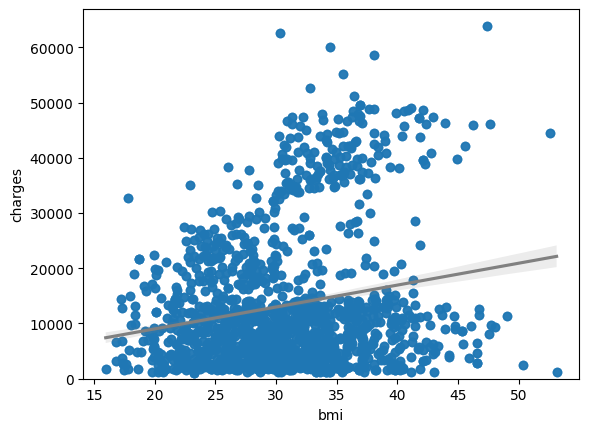

In [10]:
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "gray"})
plt.ylim(0,)
plt.show()

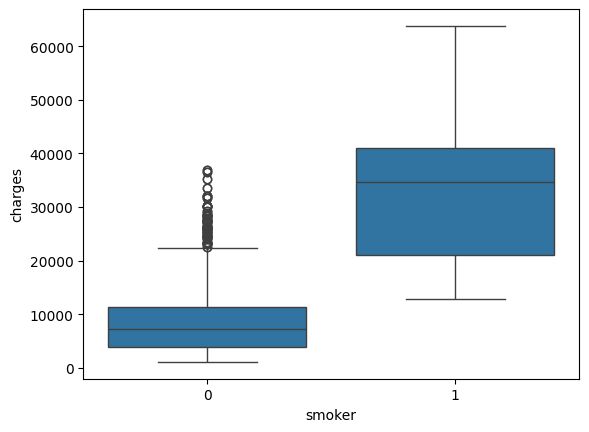

In [11]:
# boxplot of charges wrt smoker
sns.boxplot(x="smoker", y="charges", data=df)
plt.show()

In [12]:
# the correlation matrix for dataset
df.corr()

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.007167,0.298624
gender,-0.026046,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007167,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


# Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.

In [13]:
x = df[['smoker']]
y = df[['charges']]
lr = LinearRegression()
lr.fit(x,y)

LinearRegression()

In [14]:
print("The r-square value is: ", lr.score(x,y))

The r-square value is:  0.6221791733924185


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model.

In [15]:
x1 = df.drop('charges',axis=1)
lr1 = LinearRegression()
lr1.fit(x1,y)
print("The r-square value is: ", lr1.score(x1,y))

The r-square value is:  0.7504083820289634


#### Create a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There should be even further improvement in the performance.

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score


In [17]:
features = [('Std.Scaler', StandardScaler()), ('Poly.Feat', PolynomialFeatures()), ('LRegression', LinearRegression())]
pipe = Pipeline(features)
x2 = x1.astype(float)
pipe.fit(x2,y)
pipe

Pipeline(steps=[('Std.Scaler', StandardScaler()),
                ('Poly.Feat', PolynomialFeatures()),
                ('LRegression', LinearRegression())])

In [18]:
print("The r-square value is: ", pipe.score(x2,y))

The r-square value is:  0.8452576213500093


In [19]:
y_pipe = pipe.predict(x2) # same as above
print("The r-square is: ", r2_score(y, y_pipe))

The r-square is:  0.8452576213500093


# Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [20]:
x_train, x_test, y_train, y_test =train_test_split(x2,y, test_size = 0.2, random_state=1)

#### Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fit the model using training data data subset. Print the $ R^2 $ score for the testing data.


In [21]:
rr = Ridge(alpha=0.1)
rr.fit(x_train, y_train)
rr_hat = rr.predict(x_test)
print("The r-square value is: ", r2_score(y_test, rr_hat))

The r-square value is:  0.6760807731582404


#### Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, using the training subset. Print the score for the testing subset.

In [22]:
pf = PolynomialFeatures(degree=2)
xtrain_pf = pf.fit_transform(x_train)
xtest_pf = pf.fit_transform(x_test)


In [23]:
# fit the test and train transforms to the regression model
rr.fit(xtrain_pf, y_train)
rr_hat2 = rr.predict(xtest_pf)
print("The r-square value of the model is: ", r2_score(y_test, rr_hat2))

The r-square value of the model is:  0.7835631107608146
